In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import json

## Carga y exploración del dataset

In [117]:
df = pd.read_csv("food_price_inflation.csv", parse_dates=["TIME_PERIOD"])
df = df.rename(columns={
    "REF_AREA": "country",
    "REF_AREA_LABEL": "country_name",
    "TIME_PERIOD": "date",
    "OBS_VALUE": "inflation"
})
df = df.sort_values(["country", "date"]).reset_index(drop=True)
df.head(10)

,country,country_name,date,inflation
0,ABW,Aruba,2001-01-01,4.287808
1,ABW,Aruba,2001-02-01,4.425079
2,ABW,Aruba,2001-03-01,4.030159
3,ABW,Aruba,2001-04-01,4.056972
4,ABW,Aruba,2001-05-01,3.753138
5,ABW,Aruba,2001-06-01,4.196718
6,ABW,Aruba,2001-07-01,3.672698
7,ABW,Aruba,2001-08-01,3.873451
8,ABW,Aruba,2001-09-01,3.870990
9,ABW,Aruba,2001-10-01,4.073828


In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59839 entries, 0 to 59838
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   country       59839 non-null  object        
 1   country_name  59839 non-null  object        
 2   date          59839 non-null  datetime64[ns]
 3   inflation     59839 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 1.8+ MB


In [119]:
df.describe()

,date,inflation
count,59839,59839.000000
mean,2013-02-21 08:26:29.224418816,45.477730
min,2001-01-01 00:00:00,-24.982988
25%,2007-02-01 00:00:00,1.497504
50%,2013-03-01 00:00:00,4.091723
75%,2019-04-01 00:00:00,8.585937
max,2025-06-01 00:00:00,371537.503265
std,NaN,2864.567081


In [120]:
print(f"Países únicos:        {df['country'].nunique()}")
print(f"Rango de fechas:      {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Total observaciones:  {len(df)}")

Países únicos:        206
Rango de fechas:      2001-01-01 → 2025-06-01
Total observaciones:  59839


## Visualización histórica para un país de ejemplo

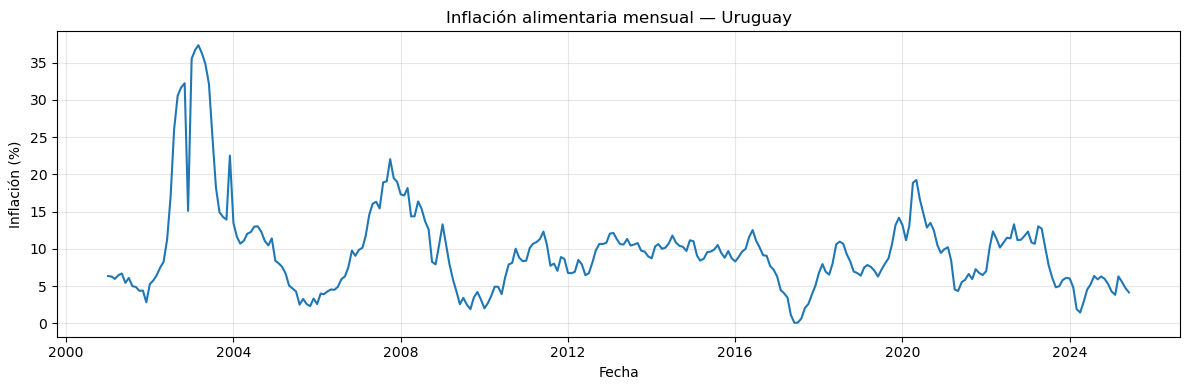

In [121]:
COUNTRY = "URY"

pais = df[df["country"] == COUNTRY].sort_values("date")

plt.figure(figsize=(12, 4))
plt.plot(pais["date"], pais["inflation"], linewidth=1.5)
plt.title(f"Inflación alimentaria mensual — {pais['country_name'].iloc[0]}")
plt.xlabel("Fecha")
plt.ylabel("Inflación (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Creación de features

El modelo recibe el par **(país, fecha)** y predice la inflación de ese mes.

Features:
- `country_enc` — país codificado numéricamente
- `year` — año extraído de la fecha
- `month` — mes extraído de la fecha

In [122]:
le = LabelEncoder()
df["country_enc"] = le.fit_transform(df["country"])
df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.month

df[["country", "country_enc", "date", "year", "month", "inflation"]].head(10)

,country,country_enc,date,year,month,inflation
0,ABW,0,2001-01-01,2001,1,4.287808
1,ABW,0,2001-02-01,2001,2,4.425079
2,ABW,0,2001-03-01,2001,3,4.030159
3,ABW,0,2001-04-01,2001,4,4.056972
4,ABW,0,2001-05-01,2001,5,3.753138
5,ABW,0,2001-06-01,2001,6,4.196718
6,ABW,0,2001-07-01,2001,7,3.672698
7,ABW,0,2001-08-01,2001,8,3.873451
8,ABW,0,2001-09-01,2001,9,3.870990
9,ABW,0,2001-10-01,2001,10,4.073828


## Split temporal

Para series temporales el split debe ser **cronológico**, no aleatorio, para evitar filtrar datos futuros al entrenamiento.

- **Train**: todo antes del penúltimo año
- **Validación**: penúltimo año completo
- **Test**: último año completo (mide efectividad final del modelo)

In [123]:
FEATURE_COLS = ["country_enc", "year", "month"]

max_date   = df["date"].max()
test_start = max_date - pd.DateOffset(years=1) + pd.DateOffset(months=1)
val_start  = test_start - pd.DateOffset(years=1)

df_train = df[df["date"] < val_start]
df_val   = df[(df["date"] >= val_start) & (df["date"] < test_start)]
df_test  = df[df["date"] >= test_start]

print(f"Train:      {df_train['date'].min().date()} → {df_train['date'].max().date()}  ({len(df_train)} obs)")
print(f"Validación: {df_val['date'].min().date()} → {df_val['date'].max().date()}  ({len(df_val)} obs)")
print(f"Test:       {df_test['date'].min().date()} → {df_test['date'].max().date()}  ({len(df_test)} obs)")

Train:      2001-01-01 → 2023-06-01  (55239 obs)
Validación: 2023-07-01 → 2024-06-01  (2400 obs)
Test:       2024-07-01 → 2025-06-01  (2200 obs)


In [124]:
X_train = df_train[FEATURE_COLS].values;  y_train = df_train["inflation"].values
X_val   = df_val[FEATURE_COLS].values;    y_val   = df_val["inflation"].values
X_test  = df_test[FEATURE_COLS].values;   y_test  = df_test["inflation"].values

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

def tolerance_accuracy(y_true, y_pred, tol):
    return np.mean(np.abs(y_pred - y_true) <= tol)

# Métricas en validación
preds_val = model.predict(X_val)
print("--- Validación ---")
print(f"MAE:                   {mean_absolute_error(y_val, preds_val):.4f}")
print(f"RMSE:                  {np.sqrt(mean_squared_error(y_val, preds_val)):.4f}")
print(f"R²:                    {r2_score(y_val, preds_val):.4f}")
print(f"Accuracy (±1pp):       {tolerance_accuracy(y_val, preds_val, 1):.4f}")
print(f"Accuracy (±2pp):       {tolerance_accuracy(y_val, preds_val, 2):.4f}")
print(f"Accuracy (±5pp):       {tolerance_accuracy(y_val, preds_val, 5):.4f}")

# Métricas en test (evaluación final — se usa una sola vez)
preds_test = model.predict(X_test)
mae  = mean_absolute_error(y_test, preds_test)
rmse = np.sqrt(mean_squared_error(y_test, preds_test))
r2   = r2_score(y_test, preds_test)
acc1 = tolerance_accuracy(y_test, preds_test, 1)
acc2 = tolerance_accuracy(y_test, preds_test, 2)
acc5 = tolerance_accuracy(y_test, preds_test, 5)

print("\n--- Test (último año) ---")
print(f"MAE:                   {mae:.4f}")
print(f"RMSE:                  {rmse:.4f}")
print(f"R²:                    {r2:.4f}")
print(f"Accuracy (±1pp):       {acc1:.4f}")
print(f"Accuracy (±2pp):       {acc2:.4f}")
print(f"Accuracy (±5pp):       {acc5:.4f}")

--- Validación ---
MAE:                   11.9069
RMSE:                  31.7595
R²:                    0.0506
Accuracy (±1pp):       0.1058
Accuracy (±2pp):       0.2042
Accuracy (±5pp):       0.4329

--- Test (último año) ---
MAE:                   14.2559
RMSE:                  31.6081
R²:                    -1.8956
Accuracy (±1pp):       0.0550
Accuracy (±2pp):       0.1032
Accuracy (±5pp):       0.2714


In [125]:
X_train[5:]


array([[   0, 2001,    6],
       [   0, 2001,    7],
       [   0, 2001,    8],
       ...,
       [ 205, 2023,    4],
       [ 205, 2023,    5],
       [ 205, 2023,    6]], shape=(55234, 3))

## Visualización: predicciones vs reales

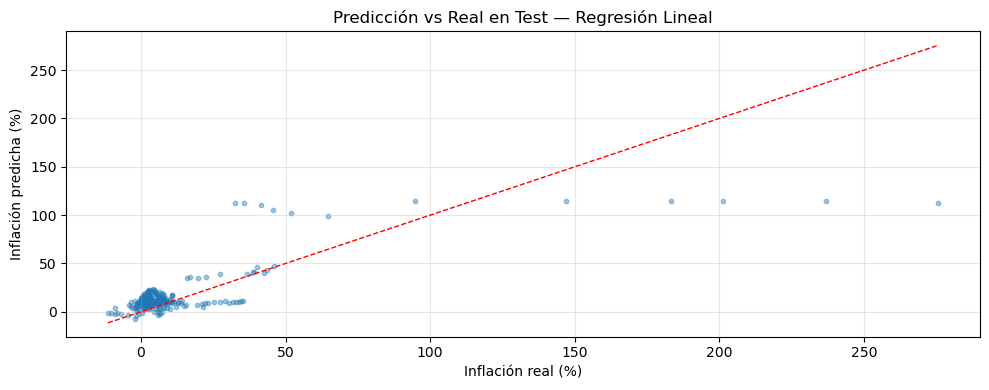

In [126]:
plt.figure(figsize=(10, 4))
plt.scatter(y_test[:300], preds_test[:300], alpha=0.4, s=10)
lim = [y_test[:300].min(), y_test[:300].max()]
plt.plot(lim, lim, "r--", linewidth=1)
plt.xlabel("Inflación real (%)")
plt.ylabel("Inflación predicha (%)")
plt.title("Predicción vs Real en Test — Regresión Lineal")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Predicción: próximos 12 meses para un país

Dado un país, generamos predicciones mes a mes para el año siguiente al último dato disponible.

In [127]:
def predict_next_12_months(country_code: str, model, le, df) -> pd.DataFrame:
    if country_code not in le.classes_:
        raise ValueError(f"País '{country_code}' no está en el dataset")

    country_enc = le.transform([country_code])[0]
    last_date = df[df["country"] == country_code]["date"].max()
    future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq="MS")

    rows = []
    for date in future_dates:
        X = np.array([[country_enc, date.year, date.month]])
        pred = model.predict(X)[0]
        rows.append({"date": date, "inflation_pred": round(pred, 2)})

    return pd.DataFrame(rows)

In [128]:
COUNTRY = "URY"

forecast = predict_next_12_months(COUNTRY, model, le, df)
print(f"Predicciones para {COUNTRY} — próximos 12 meses:")
print(forecast.to_string(index=False))

Predicciones para URY — próximos 12 meses:
      date  inflation_pred
2025-07-01           11.27
2025-08-01           11.53
2025-09-01           12.27
2025-10-01           11.34
2025-11-01           11.41
2025-12-01           11.63
2026-01-01           11.45
2026-02-01           11.14
2026-03-01           11.09
2026-04-01           12.40
2026-05-01           12.20
2026-06-01           10.02


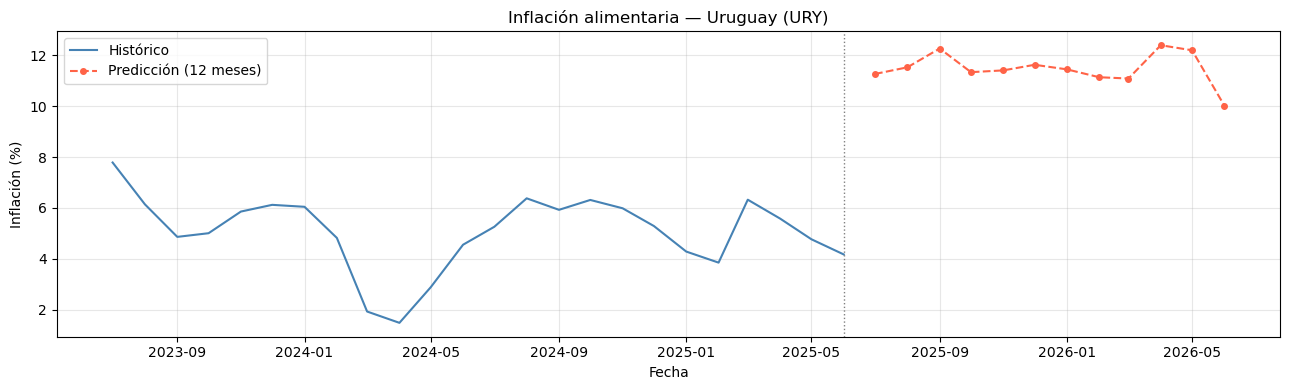

In [129]:
# Datos históricos del país para contexto
historico = df[df["country"] == COUNTRY].sort_values("date").tail(24)
nombre = df[df["country"] == COUNTRY]["country_name"].iloc[0]

plt.figure(figsize=(13, 4))
plt.plot(historico["date"], historico["inflation"], label="Histórico", linewidth=1.5, color="steelblue")
plt.plot(forecast["date"], forecast["inflation_pred"], label="Predicción (12 meses)",
         linewidth=1.5, linestyle="--", color="tomato", marker="o", markersize=4)
plt.axvline(historico["date"].iloc[-1], color="gray", linestyle=":", linewidth=1)
plt.title(f"Inflación alimentaria — {nombre} ({COUNTRY})")
plt.xlabel("Fecha")
plt.ylabel("Inflación (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [130]:
# Comparar varios países
for code in ["ARG", "BRA", "URY", "USA"]:
    f = predict_next_12_months(code, model, le, df)
    nombre = df[df["country"] == code]["country_name"].iloc[0]
    print(f"\n{nombre} ({code}):")
    print(f"  Min: {f['inflation_pred'].min():.2f}%  |  Max: {f['inflation_pred'].max():.2f}%  |  Promedio: {f['inflation_pred'].mean():.2f}%")


Argentina (ARG):
  Min: 99.60%  |  Max: 114.74%  |  Promedio: 110.60%

Brazil (BRA):
  Min: 5.26%  |  Max: 11.01%  |  Promedio: 8.62%

Uruguay (URY):
  Min: 10.02%  |  Max: 12.40%  |  Promedio: 11.48%

United States (USA):
  Min: 6.39%  |  Max: 11.96%  |  Promedio: 9.98%


## Guardar modelo y métricas

In [131]:
joblib.dump({"model": model, "label_encoder": le, "features": FEATURE_COLS}, "model.pkl")

metrics = {"mae": round(mae, 4), "rmse": round(rmse, 4), "r2": round(r2, 4)}
with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Modelo guardado en model.pkl")
print("Métricas guardadas en metrics.json")

Modelo guardado en model.pkl
Métricas guardadas en metrics.json
